# 🛬 Import libs

In [5]:
%pip install opencv-python -q

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Hàm tính khoảng cách theo euclidean

In [21]:
np.random.seed(42)
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

## Định nghĩa K-mean from scrath

In [24]:
class KMeans():
    # Khởi tạo đối tượng k-mean
    def __init__(self, K=5, max_iters=100, plot_steps=False):
        self.K = K
        self.max_iters = max_iters
        self.plot_steps = plot_steps
        # list of sample indices for each cluster
        self.clusters = [[] for _ in range(self.K)]
        # the centers (mean feature vector) for each cluster
        self.centroids = []

    # Hàm dự đoán
    def predict(self, X):
        self.X = X
        self.n_samples, self.n_features = X.shape
        
        # initialize 
        random_sample_idxs = np.random.choice(self.n_samples, self.K, replace=False)
        self.centroids = [self.X[idx] for idx in random_sample_idxs]

        # Optimize clusters
        for _ in range(self.max_iters):
            # Assign samples to closest centroids (create clusters)
            self.clusters = self._create_clusters(self.centroids)
            if self.plot_steps:
                self.plot()
            # Calculate new centroids from the clusters
            centroids_old = self.centroids
            self.centroids = self._get_centroids(self.clusters)
            
            # check if clusters have changed
            if self._is_converged(centroids_old, self.centroids):
                break
            if self.plot_steps:
                self.plot()

        # Classify samples as the index of their clusters
        return self._get_cluster_labels(self.clusters)
    
    # Lấy các nhãn của cụm
    def _get_cluster_labels(self, clusters):
        # each sample will get the label of the cluster it was assigned to
        labels = np.empty(self.n_samples)
        for cluster_idx, cluster in enumerate(clusters):
            for sample_index in cluster:
                labels[sample_index] = cluster_idx
        return labels
    
    # Tạo các cụm
    def _create_clusters(self, centroids):
        # Assign the samples to the closest centroids to create clusters
        clusters = [[] for _ in range(self.K)]
        for idx, sample in enumerate(self.X):
            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx)
        return clusters
    
    # Xác định các khoảng cách gần tâm nhất
    def _closest_centroid(self, sample, centroids):
        # distance of the current sample to each centroid
        distances = [euclidean_distance(sample, point) for point in centroids]
        closest_index = np.argmin(distances)
        return closest_index
    
    # Lấy giá trị điểm trung tâm của cụm
    def _get_centroids(self, clusters):
        # assign mean value of clusters to centroids
        centroids = np.zeros((self.K, self.n_features))
        for cluster_idx, cluster in enumerate(clusters):
            cluster_mean = np.mean(self.X[cluster], axis=0)
            centroids[cluster_idx] = cluster_mean
        return centroids
    
    def _is_converged(self, centroids_old, centroids):
        # distances between each old and new centroids, fol all centroids
        distances = [euclidean_distance(centroids_old[i], centroids[i]) for i in range(self.K)]
        return sum(distances) == 0
    
    def plot(self):
        fig, ax = plt.subplots(figsize=(12, 8))
        for i, index in enumerate(self.clusters):
            point = self.X[index].T
            ax.scatter(*point)
        for point in self.centroids:
            ax.scatter(*point, marker="x", color='black', linewidth=2)
        plt.show()

    def cent(self):
        return self.centroids

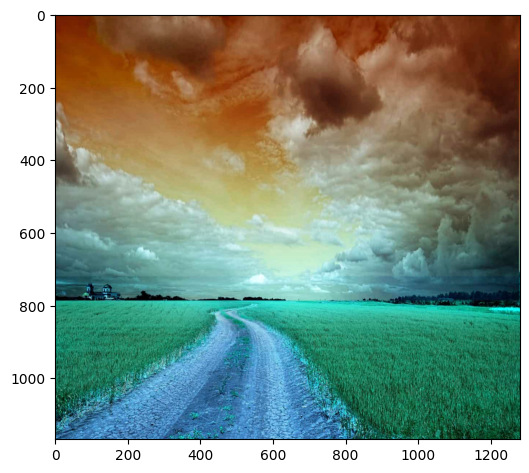

In [32]:
# Read image no filler
image = cv2.imread("./Depositphotos_31146757_l-2015-1280x1168.jpg")
plt.figure(figsize=(6, 6))
plt.imshow(image)

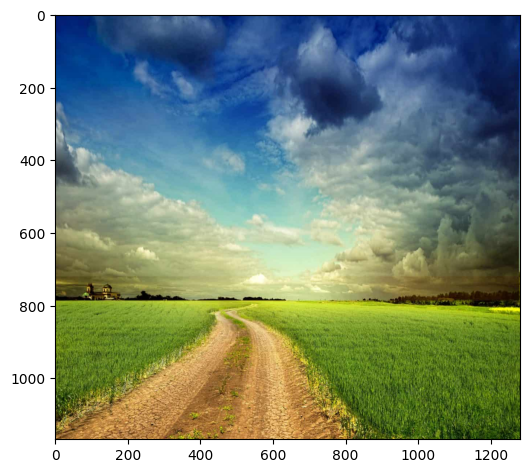

In [ ]:
# Read image with RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6)) 
plt.imshow(image)

In [34]:
pixel_values = image.reshape((-1, 3))
pixel_values = np.float32(pixel_values)
print(pixel_values.shape)

(1495040, 3)


In [36]:
k = KMeans(K=5, max_iters=100)  
y_pred = k.predict(pixel_values) 
k.cent()        

array([[ 90.39147949, 130.06266785, 157.80802917],
       [ 80.0289917 ,  97.02282715,  27.40028   ],
       [ 27.88642311,  64.03972626, 121.40912628],
       [187.24603271, 198.63563538, 160.27745056],
       [157.77131653, 151.20414734,  64.60723877]])

In [40]:
centers = np.uint8(k.cent())
centers

array([[ 90, 130, 157],
       [ 80,  97,  27],
       [ 27,  64, 121],
       [187, 198, 160],
       [157, 151,  64]], dtype=uint8)

In [41]:
y_pred

array([2, 2, 2, ..., 1, 1, 1], shape=(1495040,))

In [42]:
y_pred = y_pred.astype(int)
np.unique(y_pred)

array([0, 1, 2, 3, 4])

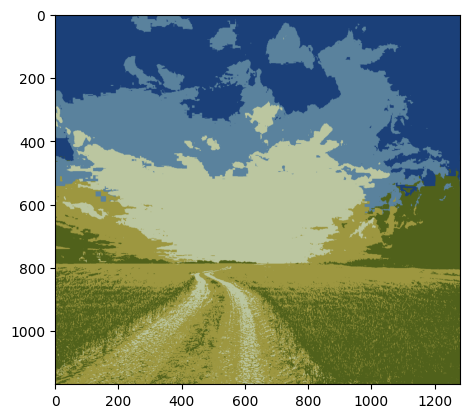

In [43]:
labels = y_pred.flatten()
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(image.shape)
plt.imshow(segmented_image)
plt.show()

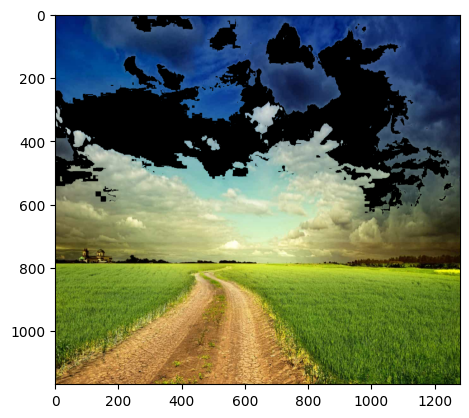

In [49]:
masked_image = np.copy(image)
masked_image = masked_image.reshape((-1, 3))
cluster = 0
masked_image[labels == cluster] = [0, 0, 0]
masked_image = masked_image.reshape(image.shape)
plt.imshow(masked_image)
plt.show()

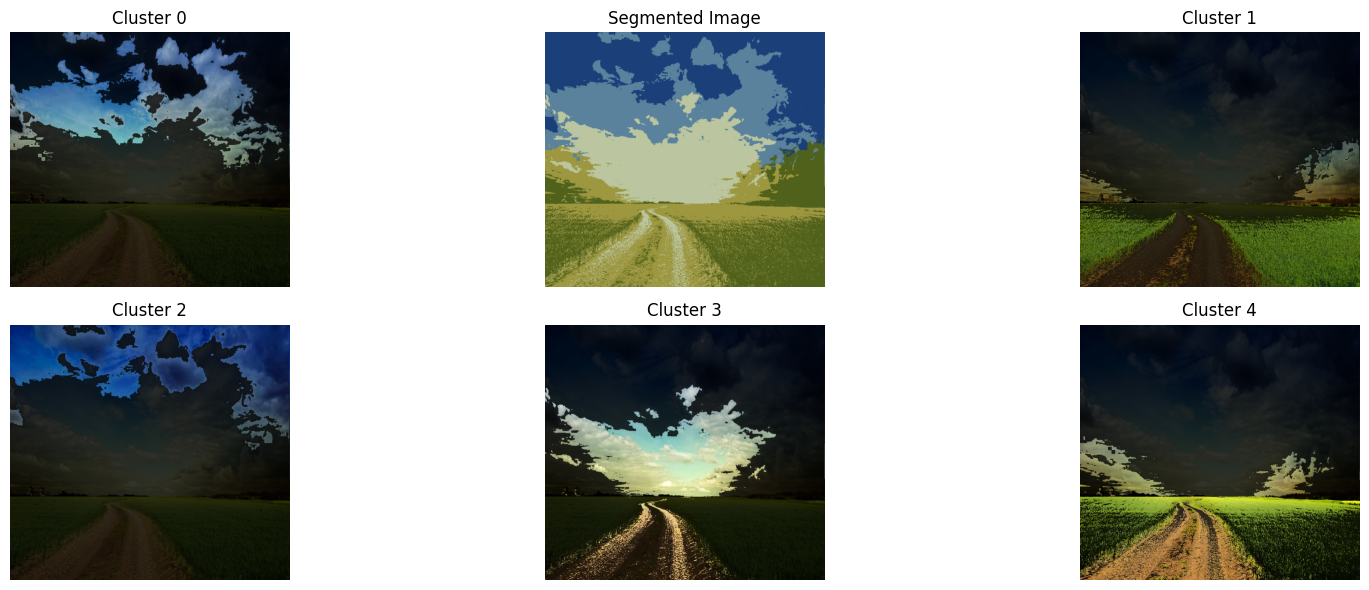

In [55]:
k = 5  # số cluster
plt.figure(figsize=(18, 6))

# Vị trí subplot: 2 hàng x 3 cột
# Index subplot từ 1 → 6

# 1. Hình tổng ở trung tâm (hàng 1, cột 2 → index=2)
plt.subplot(2, 3, 2)
plt.imshow(segmented_image)
plt.title('Segmented Image')
plt.axis('off')

# 2. Hiển thị từng cluster riêng lẻ
# Các vị trí còn lại: 1, 3, 4, 5, 6
subplot_positions = [1, 3, 4, 5, 6]

for i, cluster in enumerate(range(k)):
    masked_image = np.copy(image).astype(np.float32)
    masked_flat = masked_image.reshape((-1, 3))
    
    # Dim tất cả pixel không thuộc cluster
    masked_flat[labels != cluster] *= 0.2
    masked_image = masked_flat.reshape(image.shape).astype(np.uint8)
    
    plt.subplot(2, 3, subplot_positions[i])
    plt.imshow(masked_image)
    plt.title(f'Cluster {cluster}')
    plt.axis('off')

plt.tight_layout()
plt.show()

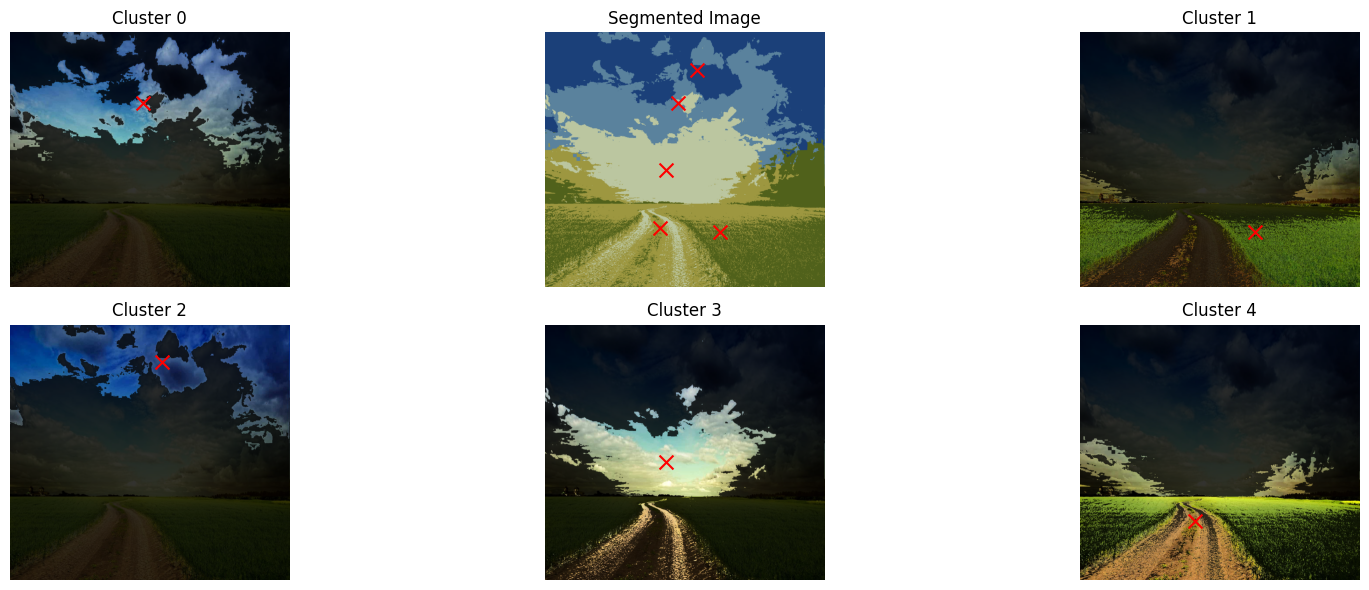

In [59]:
import matplotlib.pyplot as plt
import numpy as np

k = 5  # số cluster
plt.figure(figsize=(18, 6))

# Vị trí subplot: 2 hàng x 3 cột
# Index subplot từ 1 → 6
subplot_positions = [1, 2, 3, 4, 5, 6]

# 1. Hình tổng (segmented_image) + vẽ tâm cụm
plt.subplot(2, 3, 2)  # trung tâm
plt.imshow(segmented_image)
plt.axis('off')
plt.title('Segmented Image')

# Vẽ tâm cụm trên ảnh tổng
for cluster in range(k):
    cluster_idx = (labels == cluster).reshape(image.shape[:2])
    coords = np.argwhere(cluster_idx)
    if coords.size > 0:
        y, x = coords.mean(axis=0)
        plt.scatter(x, y, c='red', marker='x', s=100)

# 2. Hiển thị từng cluster riêng lẻ + vẽ tâm
cluster_positions = [1, 3, 4, 5, 6]  # các subplot còn lại
for i, cluster in enumerate(range(k)):
    masked_image = np.copy(image).astype(np.float32)
    masked_flat = masked_image.reshape((-1, 3))
    
    # Dim tất cả pixel không thuộc cluster
    masked_flat[labels != cluster] *= 0.2
    masked_image = masked_flat.reshape(image.shape).astype(np.uint8)
    
    # Tọa độ trung bình pixel của cluster
    cluster_idx = (labels == cluster).reshape(image.shape[:2])
    coords = np.argwhere(cluster_idx)
    if coords.size > 0:
        y, x = coords.mean(axis=0)
    
    plt.subplot(2, 3, cluster_positions[i])
    plt.imshow(masked_image)
    plt.scatter(x, y, c='red', marker='x', s=100)  # vẽ tâm
    plt.title(f'Cluster {cluster}')
    plt.axis('off')

plt.tight_layout()
plt.show()
